In [1]:
import os
import glob
import re
import h5py
import numpy as np
import networkx as nx
import math

# 1. FUNZIONE PER CREARE IL GRAFO BASE
def create_cardiac_knowledge_graph():
    G = nx.DiGraph()
    G.add_node("LA", type="chamber")
    G.add_node("LV", type="chamber")
    
    # --- NUOVI NODI TEMPORALI/STATO ---
    G.add_node("LV_ED", type="state", phase="diastole") # End-Diastole
    G.add_node("LV_ES", type="state", phase="systole")  # End-Systole
    
    G.add_node("Aorta", type="vessel")
    G.add_node("Systemic_Circulation", type="system")
    G.add_node("LV_Septum", type="tissue")
    G.add_node("LV_FreeWall", type="tissue")
    
    # Archi anatomici originali
    G.add_edges_from([("LA", "LV", {"relation": "flows_to"}), 
                      ("LV", "Aorta", {"relation": "flows_to"}),
                      ("Aorta", "Systemic_Circulation", {"relation": "flows_to"})])
    G.add_edges_from([("LV", "LV_Septum", {"relation": "bounds"}), 
                      ("LV", "LV_FreeWall", {"relation": "bounds"})])
                      
    # --- NUOVI ARCHI TEMPORALI E STRUTTURALI ---
    G.add_edges_from([
        ("LV", "LV_ED", {"relation": "has_state"}), # Il ventricolo ha uno stato diastolico
        ("LV", "LV_ES", {"relation": "has_state"}), # Il ventricolo ha uno stato sistolico
        ("LV_ED", "LV_ES", {"relation": "transitions_to"}) # Arco temporale: la diastole transita nella sistole
    ])
    
    return G

directory_path = r'/kaggle/input/datasets/anhoangvo/acdc-dataset/ACDC_preprocessed/ACDC_training_slices/'
all_files = glob.glob(os.path.join(directory_path, "*.h5"))

print(f"Trovati {len(all_files)} file .h5. Inizio aggregazione...\n")

# 3. DIZIONARIO PER AGGREGARE I DATI
# Struttura: patient_data[patient_id][frame_id] = {feature accumulate}
patient_data = {}

for file_path in all_files:
    filename = os.path.basename(file_path)
    
    # Estraiamo l'ID paziente e il frame usando le espressioni regolari
    # Es: patient001_frame01_slice_2(1).h5 -> patient001, frame01
    match = re.search(r'(patient\d+)_(frame\d+)', filename)
    if not match: continue
    
    pat_id = match.group(1)
    frame_id = match.group(2)
    
    if pat_id not in patient_data:
        patient_data[pat_id] = {}
    if frame_id not in patient_data[pat_id]:
        patient_data[pat_id][frame_id] = {"pixels_lv_sum": 0, "pixels_myo_sum": 0, "slice_count": 0}
        
    with h5py.File(file_path, 'r') as f:
        if 'label' in f.keys():
            label_data = f['label'][:]
            
            pixels_lv = np.sum(label_data == 3)
            pixels_myo = np.sum(label_data == 2)
            
            # Aggiorniamo i contatori solo se c'è effettivamente del cuore nella slice
            if pixels_lv > 0 or pixels_myo > 0:
                patient_data[pat_id][frame_id]["pixels_lv_sum"] += pixels_lv
                patient_data[pat_id][frame_id]["pixels_myo_sum"] += pixels_myo
                patient_data[pat_id][frame_id]["slice_count"] += 1

# 4. CREAZIONE DEI KNOWLEDGE GRAPH PER OGNI PAZIENTE
# Dizionario che conterrà i grafi finali pronti
patient_graphs = {}

# (Costante per simulare il volume del voxel in assenza di metadati fisici reali)
voxel_volume_mm3 = 1.0 

for pat_id, frames in patient_data.items():
    # Un paziente dovrebbe avere esattamente 2 frame (Diastole e Sistole)
    if len(frames) != 2:
        continue
        
    frame_keys = list(frames.keys())
    vol_0 = frames[frame_keys[0]]["pixels_lv_sum"] * voxel_volume_mm3
    vol_1 = frames[frame_keys[1]]["pixels_lv_sum"] * voxel_volume_mm3
    
    # La Diastole (ED) è il momento in cui il ventricolo è più grande
    # La Sistole (ES) è il momento in cui è più piccolo
    if vol_0 > vol_1:
        ed_frame, es_frame = frame_keys[0], frame_keys[1]
        ed_vol, es_vol = vol_0, vol_1
    else:
        ed_frame, es_frame = frame_keys[1], frame_keys[0]
        ed_vol, es_vol = vol_1, vol_0
        
    # Calcolo Frazione di Eiezione (EF)
    ef = ((ed_vol - es_vol) / ed_vol * 100) if ed_vol > 0 else 0
    
    # Calcoli geometrici sulla fase diastolica (Baseline)
    ed_data = frames[ed_frame]
    avg_area_lv = ed_data["pixels_lv_sum"] / ed_data["slice_count"] if ed_data["slice_count"] > 0 else 0
    avg_area_myo = ed_data["pixels_myo_sum"] / ed_data["slice_count"] if ed_data["slice_count"] > 0 else 0
    
    if avg_area_lv > 0:
        radius = math.sqrt(avg_area_lv / math.pi)
        thickness = math.sqrt((avg_area_lv + avg_area_myo) / math.pi) - radius
    else:
        radius, thickness = 0.0, 0.0

# Popoliamo il Grafo per questo paziente
    G = create_cardiac_knowledge_graph()
    
    # Aggiungiamo metadati del paziente a livello di grafo
    G.graph["patient_id"] = pat_id
    G.graph["ef"] = ef
    
    # Assegniamo i volumi ai nodi temporali specifici
    G.nodes["LV_ED"]["volume"] = float(ed_vol)
    G.nodes["LV_ES"]["volume"] = float(es_vol)
    
    # Metriche generali o calcolate in diastole rimangono collegate in modo logico
    G.nodes["LV"]["ef"] = float(ef)
    G.nodes["LV_ED"]["radius"] = float(radius) # Il raggio è calcolato sul frame ED
    G.nodes["LV_Septum"]["thickness"] = float(thickness)
    G.nodes["LV_FreeWall"]["thickness"] = float(thickness)
    
    # Salviamo il grafo nel dizionario
    patient_graphs[pat_id] = G

# 5. STAMPA DEI RISULTATI (Visualizziamo i primi 3 pazienti)
print("Estrazione completata! Ecco i dati dei primi 3 pazienti elaborati:")
print("-" * 60)
for pat_id in list(patient_graphs.keys())[:3]:
    g = patient_graphs[pat_id]
    print(f"Paziente: {pat_id}")
    # ATTENZIONE: i volumi e i raggio ora sono nei nodi temporali (LV_ED)
    print(f"  -> Volume Telediastolico (LV_EDV): {g.nodes['LV_ED']['volume']:.0f} (pseudounità)")
    print(f"  -> Frazione di Eiezione (EF): {g.nodes['LV']['ef']:.1f}%")
    print(f"  -> Raggio medio cavità (r): {g.nodes['LV_ED']['radius']:.2f}")
    print(f"  -> Spessore medio parete (h): {g.nodes['LV_Septum']['thickness']:.2f}")
    # Anche il calcolo h/r usa il raggio da LV_ED
    print(f"  -> Rapporto h/r: {g.nodes['LV_Septum']['thickness'] / g.nodes['LV_ED']['radius'] if g.nodes['LV_ED']['radius'] > 0 else 0 :.3f}")
    print("-" * 60)

print(f"\nGenerati con successo Knowledge Graph per {len(patient_graphs)} pazienti.")

Trovati 1912 file .h5. Inizio aggregazione...

Estrazione completata! Ecco i dati dei primi 3 pazienti elaborati:
------------------------------------------------------------
Paziente: patient061
  -> Volume Telediastolico (LV_EDV): 7351 (pseudounità)
  -> Frazione di Eiezione (EF): 62.5%
  -> Raggio medio cavità (r): 17.10
  -> Spessore medio parete (h): 5.76
  -> Rapporto h/r: 0.337
------------------------------------------------------------
Paziente: patient067
  -> Volume Telediastolico (LV_EDV): 7699 (pseudounità)
  -> Frazione di Eiezione (EF): 59.7%
  -> Raggio medio cavità (r): 15.65
  -> Spessore medio parete (h): 5.09
  -> Rapporto h/r: 0.325
------------------------------------------------------------
Paziente: patient050
  -> Volume Telediastolico (LV_EDV): 13920 (pseudounità)
  -> Frazione di Eiezione (EF): 16.4%
  -> Raggio medio cavità (r): 21.05
  -> Spessore medio parete (h): 4.97
  -> Rapporto h/r: 0.236
------------------------------------------------------------

G

/tmp/ipykernel_55/2723023153.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


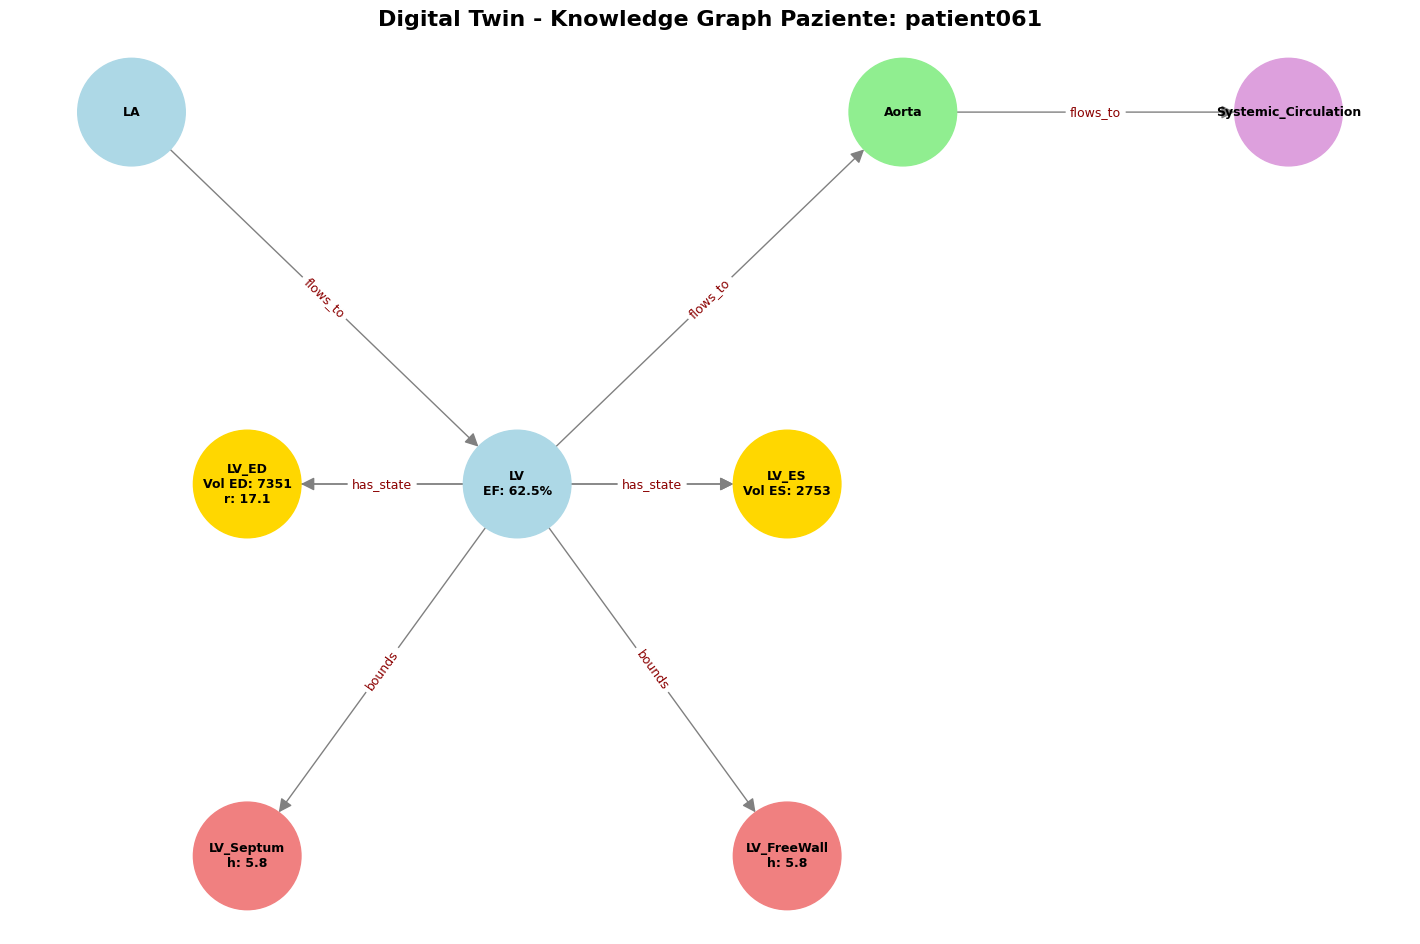

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Selezioniamo il primo paziente dal dizionario
if len(patient_graphs) > 0:
    sample_patient_id = list(patient_graphs.keys())[0]
    G_sample = patient_graphs[sample_patient_id]

    plt.figure(figsize=(14, 9))

    # 2. Layout Anatomico/Funzionale (Coordinate x, y personalizzate)
    # Aggiungiamo i nodi temporali sotto il ventricolo sinistro
    pos = {
        "LA": (0, 2),
        "LV": (1, 1),
        "LV_ED": (0.3, 1),   # Stato diastolico spostato a sinistra di LV
        "LV_ES": (1.7, 1),   # Stato sistolico spostato a destra di LV
        "Aorta": (2, 2),
        "Systemic_Circulation": (3, 2),
        "LV_Septum": (0.3, 0),
        "LV_FreeWall": (1.7, 0)
    }

    # 3. Creazione dinamica delle etichette (Mostriamo i dati estratti!)
    node_labels = {}
    for node, data in G_sample.nodes(data=True):
        label = f"{node}"
        
        # Aggiungiamo i dati biofisici in base al nodo specifico
        if node == "LV" and "ef" in data:
            label += f"\nEF: {data['ef']:.1f}%"
        elif node == "LV_ED" and "volume" in data:
            label += f"\nVol ED: {data['volume']:.0f}\nr: {data.get('radius', 0):.1f}"
        elif node == "LV_ES" and "volume" in data:
            label += f"\nVol ES: {data['volume']:.0f}"
        elif node in ["LV_Septum", "LV_FreeWall"] and "thickness" in data:
            label += f"\nh: {data['thickness']:.1f}"
            
        node_labels[node] = label

    # 4. Assegnazione dei colori in base al 'type'
    color_map = []
    for node in G_sample.nodes():
        node_type = G_sample.nodes[node].get('type', 'unknown')
        if node_type == 'chamber': color_map.append('lightblue')
        elif node_type == 'tissue': color_map.append('lightcoral')
        elif node_type == 'vessel': color_map.append('lightgreen')
        elif node_type == 'system': color_map.append('plum')
        elif node_type == 'state': color_map.append('gold') # Nuovo colore per gli stati temporali (giallo/oro)
        else: color_map.append('lightgray')

    # 5. Disegno del Grafo
    # Usiamo node_size grande per farci stare il testo
    nx.draw(G_sample, pos, with_labels=True, labels=node_labels, node_color=color_map, 
            node_size=6000, node_shape="o", font_size=9, font_weight="bold", 
            arrows=True, arrowsize=20, edge_color="gray")

    # 6. Etichette degli archi (Relazioni Causali, Fisiche e Temporali)
    edge_labels = nx.get_edge_attributes(G_sample, 'relation')
    nx.draw_networkx_edge_labels(G_sample, pos, edge_labels=edge_labels, font_size=9, font_color="darkred")

    plt.title(f"Digital Twin - Knowledge Graph Paziente: {sample_patient_id}", fontsize=16, fontweight="bold")
    plt.axis("off") # Nascondiamo gli assi cartesiani
    plt.tight_layout()
    plt.show()

else:
    print("Errore: Il dizionario patient_graphs è vuoto. Esegui prima lo script di estrazione.")

In [3]:
import pickle
import os

# 1. Definiamo il percorso di salvataggio nella cartella di output di Kaggle
save_path = '/kaggle/working/acdc_patient_graphs.pkl'

# 2. Salviamo il dizionario patient_graphs usando pickle
with open(save_path, 'wb') as f:
    pickle.dump(patient_graphs, f)

# 3. Verifichiamo che sia andato tutto a buon fine
file_size_kb = os.path.getsize(save_path) / 1024
print(f" Dataset di {len(patient_graphs)} grafi salvato con successo!")
print(f" Percorso: {save_path}")
print(f" Dimensione file: {file_size_kb:.2f} KB")

 Dataset di 100 grafi salvato con successo!
 Percorso: /kaggle/working/acdc_patient_graphs.pkl
 Dimensione file: 45.36 KB


In [4]:
import pickle

with open('/kaggle/working/acdc_patient_graphs.pkl', 'rb') as f:
    loaded_patient_graphs = pickle.load(f)

print(f"Grafi caricati: {len(loaded_patient_graphs)}")

Grafi caricati: 100


In [5]:
import pickle
import networkx as nx

# ==========================================
# 1. CARICAMENTO DEI DATI
# ==========================================
save_path = '/kaggle/working/acdc_patient_graphs.pkl'

try:
    with open(save_path, 'rb') as f:
        patient_graphs = pickle.load(f)
    print(f"Dataset caricato: {len(patient_graphs)} grafi disponibili.\n")
except FileNotFoundError:
    print("Errore: File non trovato. Assicurati di aver eseguito lo script di salvataggio.")

# ==========================================
# 2. DEFINIZIONE DEI VINCOLI HARD (Logica Simbolica)
# ==========================================
def apply_hard_constraints(G):
    """
    Applica i vincoli biofisici e diagnostici al Knowledge Graph.
    Aggiorna il grafo con etichette di validità e fenotipo.
    """
    # Estraiamo le feature chiave dai nodi
    r = G.nodes["LV_ED"]["radius"]
    h = G.nodes["LV_Septum"]["thickness"] # Usiamo il setto come riferimento
    ef = G.nodes["LV"]["ef"]
    v_td = G.nodes["LV_ED"]["volume"]
    
    # Calcoliamo il rapporto h/r
    ratio_hr = (h / r) if r > 0 else 0
    G.nodes["LV"]["h_r_ratio"] = float(ratio_hr)
    
    # ------------------------------------------------
    # VINCOLO 1: Limiti di Sopravvivenza Biologica
    # (Impostiamo soglie indicative in pseudo-unità/pixel per l'MVP)
    # ------------------------------------------------
    V_MAX_LIMIT = 100000.0  # Limite di dilatazione estrema (pseudo-mL)
    H_MAX_LIMIT = 50.0      # Limite di ipertrofia estrema (pseudo-mm)
    
    is_viable = True
    if v_td > V_MAX_LIMIT or h > H_MAX_LIMIT:
        is_viable = False
    
    G.graph["biological_viability"] = is_viable
    
    # Se il cuore non è compatibile con la vita, non lo classifichiamo oltre
    if not is_viable:
        G.graph["phenotype"] = "LETHAL_STATE"
        return G
        
    # ------------------------------------------------
    # VINCOLO 2: Classificazione Fenotipo (Regole Mediche)
    # ------------------------------------------------
    phenotype = "NOR"  # Default: Normale o non chiaramente patologico
    
    # Regola HCM: h/r > 0.45 e funzione di pompa preservata (EF >= 50%)
    if ratio_hr > 0.45 and ef >= 50.0:
        phenotype = "HCM"
        
    # Regola DCM: h/r < 0.3 e funzione di pompa compromessa (EF < 40%)
    elif ratio_hr < 0.30 and ef < 40.0:
        phenotype = "DCM"
        
    # (Opzionale) Potremmo aggiungere altre regole, es. ipertrofia eccentrica compensata
    
    G.graph["phenotype"] = phenotype
    
    return G

# ==========================================
# 3. APPLICAZIONE DEI VINCOLI AL DATASET
# ==========================================
# Contatori per le statistiche
stats = {"NOR": 0, "HCM": 0, "DCM": 0, "LETHAL_STATE": 0}

for pat_id, G in patient_graphs.items():
    # Riapplichiamo la funzione a ogni grafo aggiornandolo in-place
    patient_graphs[pat_id] = apply_hard_constraints(G)
    
    # Aggiorniamo le statistiche
    pheno = patient_graphs[pat_id].graph["phenotype"]
    stats[pheno] += 1

# ==========================================
# 4. REPORT FINALE
# ==========================================
print("-" * 40)
print("RISULTATI CLASSIFICAZIONE SIMBOLICA")
print("-" * 40)
for pat_class, count in stats.items():
    print(f"Pazienti classificati come {pat_class}: {count}")

print("\nEsempio di Paziente HCM identificato (se presente):")
for pat_id, G in patient_graphs.items():
    if G.graph["phenotype"] == "HCM":
        print(f"ID: {pat_id} | EF: {G.nodes['LV']['ef']:.1f}% | h/r: {G.nodes['LV']['h_r_ratio']:.3f}")
        break # Ne mostriamo solo uno

print("\nEsempio di Paziente DCM identificato (se presente):")
for pat_id, G in patient_graphs.items():
    if G.graph["phenotype"] == "DCM":
        print(f"ID: {pat_id} | EF: {G.nodes['LV']['ef']:.1f}% | h/r: {G.nodes['LV']['h_r_ratio']:.3f}")
        break # Ne mostriamo solo uno

# Salviamo nuovamente il dataset arricchito
with open(save_path, 'wb') as f:
    pickle.dump(patient_graphs, f)
print(f"\n✅ Dataset arricchito salvato su {save_path}")

Dataset caricato: 100 grafi disponibili.

----------------------------------------
RISULTATI CLASSIFICAZIONE SIMBOLICA
----------------------------------------
Pazienti classificati come NOR: 63
Pazienti classificati come HCM: 13
Pazienti classificati come DCM: 24
Pazienti classificati come LETHAL_STATE: 0

Esempio di Paziente HCM identificato (se presente):
ID: patient030 | EF: 74.6% | h/r: 0.667

Esempio di Paziente DCM identificato (se presente):
ID: patient050 | EF: 16.4% | h/r: 0.236

✅ Dataset arricchito salvato su /kaggle/working/acdc_patient_graphs.pkl


In [6]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00a 0:00:01


In [7]:
import torch
from torch_geometric.data import HeteroData
import pickle

# ==========================================
# 1. CARICAMENTO DEL DATASET NETWORKX
# ==========================================
save_path = '/kaggle/working/acdc_patient_graphs.pkl'
with open(save_path, 'rb') as f:
    nx_graphs = pickle.load(f)

print(f"Inizio conversione di {len(nx_graphs)} grafi in formato PyTorch Geometric...\n")


# 2. FUNZIONE DI CONVERSIONE
# ==========================================
def convert_to_pyg_heterodata(nx_graph):
    data = HeteroData()
    
    # Dizionari per mappare i nomi dei nodi a indici interi
    # AGGIUNTO: 'state' per i nodi temporali LV_ED e LV_ES
    node_mapping = {'chamber': {}, 'tissue': {}, 'vessel': {}, 'system': {}, 'state': {}}
    
    # Liste temporanee per raccogliere le feature (diventeranno tensori)
    # AGGIUNTO: 'state'
    features = {'chamber': [], 'tissue': [], 'vessel': [], 'system': [], 'state': []}
    
    # --- A. COSTRUZIONE DEI NODI E DELLE FEATURE ---
    for node_id, node_data in nx_graph.nodes(data=True):
        n_type = node_data.get('type', 'unknown')
        
        # Ignoriamo nodi senza tipo
        if n_type not in node_mapping:
            continue
            
        # Assegniamo un indice numerico a questo nodo
        idx = len(node_mapping[n_type])
        node_mapping[n_type][node_id] = idx
        
        # Estraiamo le feature vettoriali in base al tipo
        if n_type == 'chamber':
            # Il nodo LV principale ora ha EF e h_r_ratio, ma non i volumi diretti
            feat = [
                node_data.get('ef', 0.0),
                node_data.get('h_r_ratio', 0.0)
            ]
        elif n_type == 'state': # NUOVO BLOCCO PER GLI STATI TEMPORALI
            # I nodi LV_ED e LV_ES hanno il volume e il raggio
            feat = [
                node_data.get('volume', 0.0),
                node_data.get('radius', 0.0) # ES potrebbe non avere il raggio calcolato, userà 0.0
            ]
        elif n_type == 'tissue':
            # Vettore feature: [thickness]
            feat = [
                node_data.get('thickness', 0.0)
            ]
        elif n_type == 'vessel':
            feat = [120.0] # Placeholder
        elif n_type == 'system':
            feat = [1.0]   # Placeholder
            
        features[n_type].append(feat)

    # Convertiamo le liste in Tensori PyTorch
    for n_type, feat_list in features.items():
        if len(feat_list) > 0:
            data[n_type].x = torch.tensor(feat_list, dtype=torch.float)

    # --- B. COSTRUZIONE DEGLI ARCHI (EDGE INDICES) ---
    # In PyG, un arco eterogeneo è definito da una tupla (nodo_sorgente, tipo_relazione, nodo_destinazione)
    edge_dict = {}
    
    for src, dst, edge_data in nx_graph.edges(data=True):
        # Assicuriamoci che i nodi abbiano un tipo valido prima di processare l'arco
        src_type = nx_graph.nodes[src].get('type')
        dst_type = nx_graph.nodes[dst].get('type')
        
        if not src_type or not dst_type:
            continue
            
        rel_type = edge_data.get('relation', 'connected_to')
        
        edge_type_tuple = (src_type, rel_type, dst_type)
        
        if edge_type_tuple not in edge_dict:
            edge_dict[edge_type_tuple] = {'src': [], 'dst': []}
            
        # Troviamo gli indici interi corrispondenti ai nomi originali
        src_idx = node_mapping[src_type][src]
        dst_idx = node_mapping[dst_type][dst]
        
        edge_dict[edge_type_tuple]['src'].append(src_idx)
        edge_dict[edge_type_tuple]['dst'].append(dst_idx)

    # Convertiamo in tensori edge_index di shape [2, num_edges]
    for edge_type_tuple, indices in edge_dict.items():
        src_tensor = torch.tensor(indices['src'], dtype=torch.long)
        dst_tensor = torch.tensor(indices['dst'], dtype=torch.long)
        data[edge_type_tuple].edge_index = torch.stack([src_tensor, dst_tensor], dim=0)

    # --- C. METADATI E LABEL ---
    # Mappiamo le stringhe a interi: NOR=0, HCM=1, DCM=2, LETHAL=-1
    pheno_map = {"NOR": 0, "HCM": 1, "DCM": 2, "LETHAL_STATE": -1}
    pheno_str = nx_graph.graph.get('phenotype', 'NOR')
    data.y = torch.tensor([pheno_map.get(pheno_str, 0)], dtype=torch.long)
    data.patient_id = nx_graph.graph.get('patient_id', 'unknown')

    return data

# ==========================================
# 3. CREAZIONE DELLA LISTA DI GRAFI PYG
# ==========================================
pyg_dataset = []
for pat_id, nx_g in nx_graphs.items():
    pyg_data = convert_to_pyg_heterodata(nx_g)
    pyg_dataset.append(pyg_data)

# Salviamo il dataset PyG su disco
pyg_save_path = '/kaggle/working/acdc_pyg_dataset.pt'
torch.save(pyg_dataset, pyg_save_path)

# ==========================================
# 4. ISPEZIONE DEL RISULTATO
# ==========================================
print(f"✅ Conversione completata. Dataset salvato in {pyg_save_path}")
print("-" * 50)
sample = pyg_dataset[0]
print(f"Esempio: Paziente {sample.patient_id} (Classe: {sample.y.item()})")
print(sample)
print("\nFeature del nodo 'chamber' (LV e LA):")
print(sample['chamber'].x)
print("\nArchi tra 'chamber' e 'tissue' (bounds):")
print(sample[('chamber', 'bounds', 'tissue')].edge_index)

Inizio conversione di 100 grafi in formato PyTorch Geometric...

✅ Conversione completata. Dataset salvato in /kaggle/working/acdc_pyg_dataset.pt
--------------------------------------------------
Esempio: Paziente patient061 (Classe: 0)
HeteroData(
  y=[1],
  patient_id='patient061',
  chamber={ x=[2, 2] },
  tissue={ x=[2, 1] },
  vessel={ x=[1, 1] },
  system={ x=[1, 1] },
  state={ x=[2, 2] },
  (chamber, flows_to, chamber)={ edge_index=[2, 1] },
  (chamber, flows_to, vessel)={ edge_index=[2, 1] },
  (chamber, bounds, tissue)={ edge_index=[2, 2] },
  (chamber, has_state, state)={ edge_index=[2, 2] },
  (state, transitions_to, state)={ edge_index=[2, 1] },
  (vessel, flows_to, system)={ edge_index=[2, 1] }
)

Feature del nodo 'chamber' (LV e LA):
tensor([[ 0.0000,  0.0000],
        [62.5493,  0.3369]])

Archi tra 'chamber' e 'tissue' (bounds):
tensor([[1, 1],
        [0, 1]])


In [8]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, Linear

class DigitalTwinGNN(nn.Module):
    """
    GNN eterogenea spazio-temporale che predice DELTA geometrici (Δh, Δr ).
    Include la dinamica del ciclo cardiaco tramite i nodi 'state'.
    """
    def __init__(self, hidden_channels=32):
        super().__init__()

        # 1. ENCODER AGGIORNATI (Le dimensioni riflettono i vettori estratti in PyG)
        self.encoder = nn.ModuleDict({
            "chamber": Linear(2, hidden_channels), # feature: [ef, h_r_ratio]
            "state":   Linear(2, hidden_channels), # feature: [volume, radius] (NUOVO NODO)
            "tissue":  Linear(1, hidden_channels), # feature: [thickness]
            "vessel":  Linear(1, hidden_channels), # feature: [pressure]
            "system":  Linear(1, hidden_channels), # feature: [resistance]
        })

        # 2. CONVOLUZIONI (Aggiunto il Message Passing temporale)
        self.conv1 = HeteroConv({
            # Archi Spaziali/Anatomici
            ("chamber", "bounds",   "tissue"):  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            ("chamber", "flows_to", "chamber"): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            ("chamber", "flows_to", "vessel"):  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            # Archi Temporali/Stato (NUOVI)
            ("chamber", "has_state", "state"):  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            ("state", "transitions_to", "state"): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
        }, aggr="sum")

        self.conv2 = HeteroConv({
            # Archi Spaziali
            ("chamber", "bounds",   "tissue"):  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            ("chamber", "flows_to", "chamber"): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            # Archi Temporali (NUOVI)
            ("chamber", "has_state", "state"):  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
            ("state", "transitions_to", "state"): SAGEConv((hidden_channels, hidden_channels), hidden_channels),
        }, aggr="sum")

        # 3. DECODER
        # Predice Δh (spessore) agendo sul miocardio
        self.predict_tissue = Linear(hidden_channels, 2)  # [Δh, Δmassa]        
        # Predice ΔV e Δr agendo sui nodi temporali (es. sulla diastole)
        self.predict_state  = Linear(hidden_channels, 2)  # [ΔV, Δr] 

    def forward(self, x_dict, edge_index_dict):
        # Encoding iniziale di tutte le feature
        h = {t: F.leaky_relu(self.encoder[t](x), negative_slope=0.1)
             for t, x in x_dict.items() if t in self.encoder} # Sicurezza extra

        # Message passing Layer 1
        h_out = self.conv1(h, edge_index_dict)
        for k, v in h_out.items():
            h[k] = F.leaky_relu(v, negative_slope=0.1)

        # Message passing Layer 2
        h_out = self.conv2(h, edge_index_dict)
        for k, v in h_out.items():
            h[k] = F.leaky_relu(v, negative_slope=0.1)

        # Output lineare — restituiamo i delta predetti
        return {
            "delta_tissue": self.predict_tissue(h["tissue"]),
            "delta_state":  self.predict_state(h["state"]), # Ora chiamiamo il predict sugli stati
        }

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuroSymbolicLoss(nn.Module):
    """
    Multi-task loss con tre componenti (§5.2 LaTeX) + Conservazione Massa:
      L_tot = α·L_physics + β·L_excl + γ·L_data + δ·L_massa + L_dir + L_reg
 
    L_physics : rispetto della Legge di Laplace (stress ratio → 1)
    L_excl    : mutua esclusione HCM/DCM (§3.1.4)
    L_data    : target geometrico paziente-specifico
    L_reg     : regolarizzazione L2 sui delta (evita esplosione)
    L_dir     : vincolo di segno — in HCM dh deve essere > 0
    L_massa   : vincolo di conservazione della massa
   
    """
    def __init__(self, sigma_0=120.0, alpha=1.0, beta=2.0,
                 gamma=1.0, delta_m=1.0, delta_reg=0.05):
        super().__init__()
        self.sigma_0   = sigma_0
        self.alpha     = alpha
        self.beta      = beta
        self.gamma     = gamma
        self.delta_m   = delta_m 
        self.delta_reg = delta_reg

    def forward(self, delta_state, delta_tissue,
                stress_in, r_base, h_base, epoch,
                h_target, r_target):

        # --- Activation: quanto siamo sopra la soglia di rimodellamento ---
        activation = F.relu(stress_in - self.sigma_0) / (stress_in + 1e-6)

        # --- Delta geometrici ---
        # delta_tissue ha shape [1, 1] (solo Δh). Lo clampiamo
        dh = torch.clamp(delta_tissue[:, 0],  min=-4.0, max=4.0) * activation
        dm = torch.clamp(delta_tissue[:, 1], min=-1.0, max=0.05) * activation # Predizione massa
        
        # delta_state ha shape [2, 2] (ED, ES e per ognuno [ΔV, Δr]). 
        # Estraiamo il Δr (indice 1) dello stato diastolico (indice 0)
        dr = torch.clamp(delta_state[0, 1], min=-4.0, max=4.0) * activation
        
        # delta_v (opzionale per futuri sviluppi, indice 0 dello stato diastolico)
        dv = torch.clamp(delta_state[0, 0], min=-50.0, max=50.0) * activation

        # Geometria finale calcolata sulle variazioni
        h_nuovo = F.softplus(h_base + dh)   
        r_nuovo = F.softplus(r_base + dr)   
        
        # Medie per comodità di calcolo (es. se ci sono più nodi setto/parete)
        h_base_m = h_base.mean()
        h_nuovo_m = h_nuovo.mean()

        # --- L_physics: Laplace ---
        p_syst        = (stress_in * 2.0 * h_base_m) / (r_base + 1e-6)
        stress_finale = (p_syst * r_nuovo) / (2.0 * h_nuovo_m + 1e-6)
        ratio_stress  = stress_finale / (stress_in + 1e-6)
        loss_physics  = F.mse_loss(ratio_stress, torch.ones_like(ratio_stress))

        # --- L_excl: mutua esclusione HCM/DCM ---
        lambda_excl   = min(5.0, epoch * 0.05)
        loss_excl     = torch.mean(F.relu(dh) * F.relu(dr)) * lambda_excl

        # --- L_data: target geometrico ---
        loss_data = (
            F.mse_loss(h_nuovo_m / (h_base_m + 1e-6), h_target / (h_base_m + 1e-6)) +
            F.mse_loss(r_nuovo   / (r_base + 1e-6),   r_target / (r_base + 1e-6))
        )

        # --- L_massa: Conservazione/Coerenza della Massa ---
        # Calcolo Area 2D (miocardio) usando h e r
        area_base = torch.pi * (h_base_m**2 + 2.0 * r_base * h_base_m)
        area_fin  = torch.pi * (h_nuovo_m**2 + 2.0 * r_nuovo * h_nuovo_m)
               
        ratio_area_geometrica = area_fin / (area_base + 1e-6)
        ratio_area_predetto   = 1.0 + dm.mean()
        loss_massa = F.mse_loss(ratio_area_geometrica, ratio_area_predetto)

        # --- L_dir: vincolo di segno ---
        loss_dir = F.relu(-dh).mean() * 5.0

        # --- L_reg: regolarizzazione L2 ---
        loss_reg = self.delta_reg * (
            delta_tissue[:, 0].pow(2).mean() +
            delta_state[0, 1].pow(2) +  # Regolarizza dr in ED
            delta_state[0, 0].pow(2)    # Regolarizza dV in ED
        )

        # --- Loss Totale ---
        total = (self.alpha   * loss_physics +
                 self.beta    * loss_excl    +
                 self.gamma   * loss_data    +
                 self.delta_m * loss_massa   + 
                 loss_dir                    +
                 loss_reg)

        return total, loss_physics, loss_excl, loss_data, loss_dir, loss_massa

In [62]:
# Creiamo una lista di soli pazienti sani
pazienti_nor = [d for d in pyg_dataset if d.y == 0]

print(f"Pazienti totali: {len(pyg_dataset)}")
print(f"Pazienti sani (NOR) per il training: {len(pazienti_nor)}")

Pazienti totali: 100
Pazienti sani (NOR) per il training: 63


In [15]:
import torch
import torch.optim as optim
import torch.nn.functional as F

# Caricamento dataset e filtro pazienti NOR
pyg_dataset  = torch.load('/kaggle/working/acdc_pyg_dataset.pt', weights_only=False)
pazienti_nor = [d for d in pyg_dataset if d.y == 0]
print(f"Pazienti NOR per il training: {len(pazienti_nor)}")

# Inizializzazione modello
model_pop = DigitalTwinGNN(hidden_channels=32)

# Applichiamo i pesi iniziali stabili
model_pop.apply(init_weights)

optimizer     = optim.Adam(model_pop.parameters(), lr=0.001)
scheduler     = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

criterion     = NeuroSymbolicLoss(
    sigma_0=120.0, alpha=0.3, beta=2.0, gamma=3.0, delta_m=1.0, delta_reg=0.05
)

for epoch in range(201):
    model_pop.train()
    total_loss = total_lp = total_le = total_ld = total_ldir = total_lmassa = 0.0
    n_valid    = 0

    for data_p in pazienti_nor:
        optimizer.zero_grad()

        # 1. Estrazione feature base
        p_base    = 120.0 
        r_base    = data_p['state'].x[0, 1]   
        h_base    = data_p['tissue'].x[:, 0]          

        # 2. Trigger HCM
        p_ipert   = p_base * 1.5
        stress_in = (p_ipert * r_base) / (2.0 * h_base.mean() + 1e-6)

        # 3. Forward Pass
        out = model_pop(data_p.x_dict, data_p.edge_index_dict)

        # 4. Target HCM
        h_target = h_base.mean() * 1.50
        r_target = r_base        * 0.88

        # 5. Spacchettamento Loss
        loss, lp, le, ld, ldir, lmassa = criterion(
            delta_state=out['delta_state'], 
            delta_tissue=out['delta_tissue'],
            stress_in=stress_in, 
            r_base=r_base, 
            h_base=h_base, 
            epoch=epoch,
            h_target=h_target,
            r_target=r_target,
        )

        # ---> MODIFICA 1: Rimosso loss > 1000.0 <---
        if not torch.isfinite(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pop.parameters(), 1.0)
        optimizer.step()

        # Accumulo delle metriche
        total_loss   += loss.item()
        total_lp     += lp.item()
        total_le     += le.item()
        total_ld     += ld.item()
        total_ldir   += ldir.item()
        total_lmassa += lmassa.item()
        n_valid      += 1

    # ---> MODIFICA 2: Esegui il learning rate step SOLO se l'epoca è stata valida <---
    if n_valid > 0:
        scheduler.step()

    # Log
    if epoch % 20 == 0:
        if n_valid > 0:
            n = n_valid
            print(f"Epoca {epoch:03d} | "
                  f"Loss: {total_loss/n:.4f} | "
                  f"Phys: {total_lp/n:.4f} | "
                  f"Excl: {total_le/n:.4f} | "
                  f"Data: {total_ld/n:.4f} | "
                  f"Dir: {total_ldir/n:.4f} | "
                  f"Massa: {total_lmassa/n:.4f}")
        else:
            print(f"Epoca {epoch:03d} | Nessun paziente valido per l'addestramento.")

Pazienti NOR per il training: 63
Epoca 000 | Loss: 1184.7946 | Phys: 0.0354 | Excl: 0.0000 | Data: 0.1690 | Dir: 0.0677 | Massa: 0.0531
Epoca 020 | Loss: 2.4602 | Phys: 0.0184 | Excl: 0.1680 | Data: 0.1867 | Dir: 0.0000 | Massa: 0.0144
Epoca 040 | Loss: 0.6504 | Phys: 0.0268 | Excl: 0.0509 | Data: 0.1226 | Dir: 0.0000 | Massa: 0.0290
Epoca 060 | Loss: 0.5175 | Phys: 0.0274 | Excl: 0.0000 | Data: 0.1183 | Dir: 0.0000 | Massa: 0.0305
Epoca 080 | Loss: 0.5142 | Phys: 0.0278 | Excl: 0.0000 | Data: 0.1176 | Dir: 0.0000 | Massa: 0.0315
Epoca 100 | Loss: 0.5132 | Phys: 0.0282 | Excl: 0.0000 | Data: 0.1170 | Dir: 0.0000 | Massa: 0.0319
Epoca 120 | Loss: 0.5128 | Phys: 0.0282 | Excl: 0.0000 | Data: 0.1171 | Dir: 0.0000 | Massa: 0.0318
Epoca 140 | Loss: 0.5128 | Phys: 0.0283 | Excl: 0.0000 | Data: 0.1171 | Dir: 0.0000 | Massa: 0.0318
Epoca 160 | Loss: 0.5125 | Phys: 0.0282 | Excl: 0.0000 | Data: 0.1170 | Dir: 0.0000 | Massa: 0.0318
Epoca 180 | Loss: 0.5124 | Phys: 0.0283 | Excl: 0.0000 | Data: 0

In [16]:
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split

# Caricamento dataset e filtro pazienti NOR
pyg_dataset  = torch.load('/kaggle/working/acdc_pyg_dataset.pt', weights_only=False)
pazienti_nor = [d for d in pyg_dataset if d.y == 0]

# --- NUOVO: SPLIT TRAIN/TEST ---
# Fissiamo il random_state per riproducibilità
train_nor, test_nor = train_test_split(pazienti_nor, test_size=0.20, random_state=42)

print(f"Pazienti NOR Totali: {len(pazienti_nor)}")
print(f" -> Usati per il Training: {len(train_nor)}")
print(f" -> Tenuti per il Testing: {len(test_nor)}\n")

# Inizializzazione modello
model_pop = DigitalTwinGNN(hidden_channels=32)
# Assicurati di avere la funzione init_weights definita prima di chiamarla!
model_pop.apply(init_weights)

optimizer     = optim.Adam(model_pop.parameters(), lr=0.001)
scheduler     = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

criterion     = NeuroSymbolicLoss(
    sigma_0=120.0, alpha=0.3, beta=2.0, gamma=3.0, delta_m=1.0, delta_reg=0.05
)

# --- TRAINING LOOP (Itera su train_nor) ---
for epoch in range(201):
    model_pop.train()
    total_loss = total_lp = total_le = total_ld = total_ldir = total_lmassa = 0.0
    n_valid    = 0

    # ATTENZIONE: Ora iteriamo solo sui pazienti di training!
    for data_p in train_nor: 
        optimizer.zero_grad()

        # 1. Estrazione feature base paziente dalla nuova topologia
        p_base    = 120.0 # Pressione fissa di default
        r_base    = data_p['state'].x[0, 1]   # Raggio diastolico dal nodo 'state'
        h_base    = data_p['tissue'].x[:, 0]  # Spessore dal nodo 'tissue'

        # 2. Trigger HCM (Ipertensione +50%) per il training e calcolo Stress
        p_ipert   = p_base * 1.5
        stress_in = (p_ipert * r_base) / (2.0 * h_base.mean() + 1e-6)


        # 3. Forward Pass
        out = model_pop(data_p.x_dict, data_p.edge_index_dict)

        # 4. Target HCM paziente-specifico
        h_target = h_base.mean() * 1.50
        r_target = r_base        * 0.88

        # 5. Spacchettamento aggiornato (Passiamo delta_state invece di delta_chamber)
        loss, lp, le, ld, ldir, lmassa = criterion(
            delta_state=out['delta_state'],
            delta_tissue=out['delta_tissue'],
            stress_in=stress_in, 
            r_base=r_base, 
            h_base=h_base, 
            epoch=epoch,
            h_target=h_target,
            r_target=r_target,
        )

        # 6. Sicurezza Numerica (RIMOSSO il blocco loss > 1000.0)
        if not torch.isfinite(loss): 
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pop.parameters(), 1.0)
        optimizer.step()

        # Accumulo delle metriche
        total_loss   += loss.item()
        total_lp     += lp.item()
        total_le     += le.item()
        total_ld     += ld.item()
        total_ldir   += ldir.item()
        total_lmassa += lmassa.item() 
        n_valid      += 1

    scheduler.step()

    # Log ridotto (stampa ogni 40 epoche come richiesto)
    if epoch % 40 == 0:
        if n_valid > 0:
            n = n_valid
            print(f"Epoca {epoch:03d} | Loss: {total_loss/n:.4f} | Phys: {total_lp/n:.4f} | Massa: {total_lmassa/n:.4f}")
        else:
            print(f"Epoca {epoch:03d} | Attenzione: Nessun paziente valido per l'addestramento.")

Pazienti NOR Totali: 63
 -> Usati per il Training: 50
 -> Tenuti per il Testing: 13

Epoca 000 | Loss: 323.8147 | Phys: 0.0346 | Massa: 0.0627
Epoca 040 | Loss: 0.6561 | Phys: 0.0319 | Massa: 0.0362
Epoca 080 | Loss: 0.6100 | Phys: 0.0293 | Massa: 0.0321
Epoca 120 | Loss: 0.5100 | Phys: 0.0285 | Massa: 0.0318
Epoca 160 | Loss: 0.5097 | Phys: 0.0284 | Massa: 0.0320
Epoca 200 | Loss: 0.5097 | Phys: 0.0285 | Massa: 0.0320


In [17]:
# =============================================================================
# CELL 7 — Valutazione: simulazione HCM sul Test Set NOR
# =============================================================================
import pandas as pd
import torch.nn.functional as F
import torch

model_pop.eval()
risultati_hcm = []

with torch.no_grad():
    # ATTENZIONE: Ora iteriamo su test_nor per valutare pazienti MAI VISTI dalla rete!
    for i, data_p in enumerate(test_nor):
        
        # 1. Estrazione feature base dalla nuova topologia
        p_base    = 120.0 # Pressione fissa di default
        r_base    = data_p['state'].x[0, 1]   # Raggio diastolico dal nodo 'state'
        h_base    = data_p['tissue'].x[:, 0]  # Spessore dal nodo 'tissue'
        
        # 2. Trigger HCM: ipertensione +50%
        p_ipert   = p_base * 1.5
        stress_in = (p_ipert * r_base) / (2.0 * h_base.mean() + 1e-6)

        # (RIMOSSO: l'aggiornamento errato del tensore tissue)

        # 3. Predizione GNN
        out = model_pop(data_p.x_dict, data_p.edge_index_dict)

        # 4. Calcolo variazioni (delta)
        activation = F.relu(stress_in - 120.0) / (stress_in + 1e-6)
        dh = torch.clamp(out['delta_tissue'][:, 0],  -4.0, 4.0) * activation
        
        # NUOVO: Estrazione del delta raggio dal nodo temporale 'state'
        dr = torch.clamp(out['delta_state'][0, 1], -4.0, 4.0) * activation

        # 5. Geometrie finali post-rimodellamento
        h_fin = F.softplus(h_base + dh).mean().item()
        r_fin = F.softplus(r_base + dr).item()

        if h_fin < 0.1 or r_fin < 0.1:
            continue

        ratio = h_fin / r_fin

        # 6. Classificazione simbolica post-hoc (§3.1 LaTeX)
        if ratio > 0.45:
            diagnosi = "HCM"
        elif ratio < 0.30:
            diagnosi = "DCM"
        else:
            diagnosi = "NOR/Eccentrico"

        # Cerchiamo di usare l'ID originale del paziente, se disponibile, altrimenti usiamo l'indice
        pat_id = data_p.patient_id if hasattr(data_p, 'patient_id') else f"Test_{i}"

        risultati_hcm.append({
            "Paziente":   pat_id,
            "h_iniziale": h_base.mean().item(),
            "h_finale":   h_fin,
            "Δh (px)":    dh.mean().item(),
            "r_finale":   r_fin,
            "Δr (px)":    dr.item(),
            "h/r ratio":  ratio,
            "Diagnosi":   diagnosi,
        })

df_hcm = pd.DataFrame(risultati_hcm)

print("\n=== Valutazione su TEST SET: Simulazione trigger HCM (ipertensione +50%) ===")
if not df_hcm.empty:
    # Mostriamo solo 3 cifre decimali per comodità di lettura
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print(df_hcm[["Paziente", "Δh (px)", "Δr (px)", "h/r ratio", "Diagnosi"]].head(10))
    
    # Riassunto delle diagnosi predette dal Digital Twin
    print("-" * 60)
    print(f"Pazienti totali testati: {len(df_hcm)}")
    print(f" -> Fenotipo previsto HCM: {(df_hcm['Diagnosi']=='HCM').sum()}")
    print(f" -> Fenotipo previsto NOR: {(df_hcm['Diagnosi']=='NOR/Eccentrico').sum()}")
    print(f" -> Fenotipo previsto DCM: {(df_hcm['Diagnosi']=='DCM').sum()}")
else:
    print("Nessun paziente processato con successo.")


=== Valutazione su TEST SET: Simulazione trigger HCM (ipertensione +50%) ===
     Paziente  Δh (px)  Δr (px)  h/r ratio        Diagnosi
0  patient057    0.425   -0.106      0.456             HCM
1  patient097    0.893   -0.212      0.389  NOR/Eccentrico
2  patient061    0.842   -0.200      0.391  NOR/Eccentrico
3  patient077    0.938   -0.218      0.360  NOR/Eccentrico
4  patient025    0.561   -0.150      0.470             HCM
5  patient093    0.896   -0.250      0.320  NOR/Eccentrico
6  patient092    0.894   -0.223      0.359  NOR/Eccentrico
7  patient084    0.821   -0.244      0.328  NOR/Eccentrico
8  patient003    0.970   -0.170      0.356  NOR/Eccentrico
9  patient013    0.829   -0.175      0.383  NOR/Eccentrico
------------------------------------------------------------
Pazienti totali testati: 13
 -> Fenotipo previsto HCM: 3
 -> Fenotipo previsto NOR: 10
 -> Fenotipo previsto DCM: 0


In [19]:
import pandas as pd
import torch.nn.functional as F
import torch

# =============================================================================
# CELL 8 — Valutazione: simulazione DCM sul Test Set NOR
# =============================================================================

risultati_dcm = []

model_pop.eval() # Assicuriamoci di essere in eval mode
with torch.no_grad():
    # ATTENZIONE: Ora iteriamo su test_nor per valutare pazienti MAI VISTI!
    for i, data_p in enumerate(test_nor):
        temp_data = data_p.clone()

        # 1. Estrazione feature base dalla nuova topologia
        p_base     = 120.0 # Pressione di default
        r_base_ori = temp_data['state'].x[0, 1] # Raggio diastolico dal nodo 'state'
        h_base     = temp_data['tissue'].x[:, 0] # Spessore dal nodo 'tissue'

        # 2. Trigger DCM: dilatazione precarico +60%
        r_dilatato = r_base_ori * 1.6
        # Aggiorniamo temporaneamente il raggio nel nodo diastolico ('state')
        temp_data['state'].x[0, 1] = r_dilatato

        stress_dcm = (p_base * r_dilatato) / (2.0 * h_base.mean() + 1e-6)

        # (RIMOSSO l'aggiornamento della feature stress nel tessuto)

        # 3. Predizione GNN (sul grafo clonato con il raggio dilatato)
        out = model_pop(temp_data.x_dict, temp_data.edge_index_dict)

        # 4. Calcolo variazioni (delta)
        activation = F.relu(stress_dcm - 120.0) / (stress_dcm + 1e-6)
        dh = torch.clamp(out['delta_tissue'][:, 0],      -4.0, 4.0) * activation
        
        # Estrazione del delta raggio dal nodo temporale 'state'
        dr = torch.clamp(out['delta_state'][0, 1],       -4.0, 4.0) * activation
        
        # (RIMOSSO dm perché non è più un output esplicito della rete)

        # 5. Geometrie finali post-rimodellamento (partendo dalla base dilatata)
        h_fin = F.softplus(h_base     + dh).mean().item()
        r_fin = F.softplus(r_dilatato + dr).item()

        if h_fin < 0.1 or r_fin < 0.1:
            continue

        ratio = h_fin / r_fin

        # 6. Classificazione simbolica post-hoc
        if ratio < 0.30:
            diagnosi = "DCM"
        elif ratio > 0.45:
            diagnosi = "HCM"
        else:
            diagnosi = "NOR/Eccentrico"

        # Identificativo Paziente
        pat_id = data_p.patient_id if hasattr(data_p, 'patient_id') else f"Test_{i}"

        risultati_dcm.append({
            "Paziente":  pat_id,
            "h_finale":  h_fin,
            "Δh (px)":   dh.mean().item(),
            "r_finale":  r_fin,
            "Δr (px)":   dr.item(),
            "h/r ratio": ratio,
            "Diagnosi":  diagnosi,
        })

df_dcm = pd.DataFrame(risultati_dcm)

print("\n=== Valutazione su TEST SET: Simulazione trigger DCM (precarico +60%) ===")
if not df_dcm.empty:
    # Formattazione per leggerezza di output
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print(df_dcm[["Paziente", "Δh (px)", "Δr (px)", "h/r ratio", "Diagnosi"]].head(10))
    
    # Riassunto
    print("-" * 60)
    print(f"Pazienti totali testati: {len(df_dcm)}")
    print(f" -> Fenotipo previsto DCM: {(df_dcm['Diagnosi']=='DCM').sum()}")
    print(f" -> Fenotipo previsto NOR: {(df_dcm['Diagnosi']=='NOR/Eccentrico').sum()}")
    print(f" -> Fenotipo previsto HCM: {(df_dcm['Diagnosi']=='HCM').sum()}")
else:
    print("Nessun paziente processato con successo.")


=== Valutazione su TEST SET: Simulazione trigger DCM (precarico +60%) ===
     Paziente  Δh (px)  Δr (px)  h/r ratio Diagnosi
0  patient057    0.463   -0.115      0.285      DCM
1  patient097    0.936   -0.222      0.244      DCM
2  patient061    0.885   -0.210      0.245      DCM
3  patient077    0.977   -0.227      0.226      DCM
4  patient025    0.609   -0.162      0.295      DCM
5  patient093    0.924   -0.257      0.200      DCM
6  patient092    0.929   -0.231      0.225      DCM
7  patient084    0.848   -0.252      0.205      DCM
8  patient003    1.010   -0.177      0.223      DCM
9  patient013    0.872   -0.184      0.240      DCM
------------------------------------------------------------
Pazienti totali testati: 13
 -> Fenotipo previsto DCM: 13
 -> Fenotipo previsto NOR: 0
 -> Fenotipo previsto HCM: 0


/tmp/ipykernel_55/3183247864.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Trigger", y="Rapporto h/r", data=df_plot,


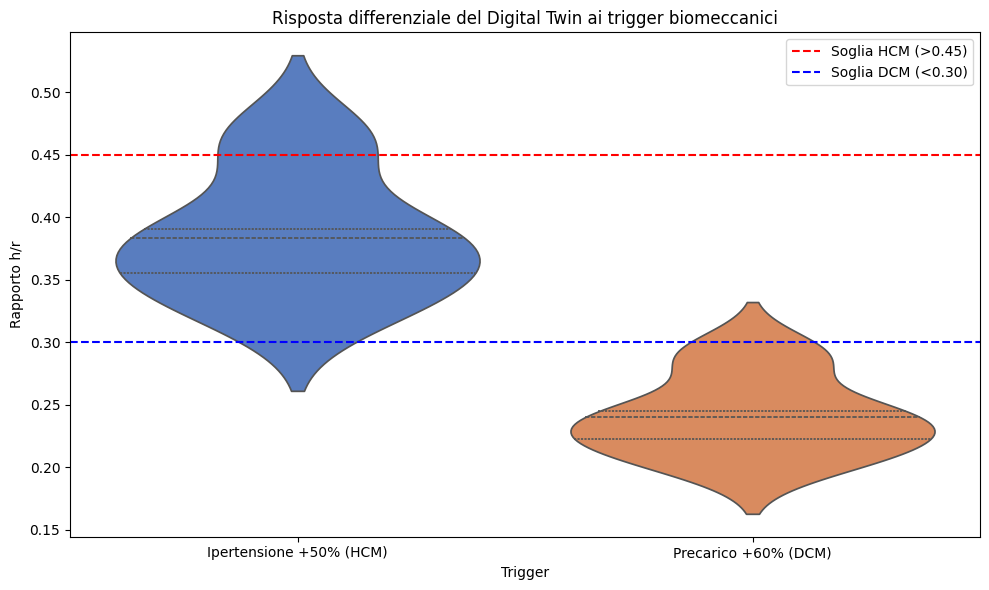

In [20]:
import seaborn as sns
 
df_plot = pd.DataFrame({
    "Rapporto h/r": list(df_hcm["h/r ratio"]) + list(df_dcm["h/r ratio"]),
    "Trigger":      ["Ipertensione +50% (HCM)"] * len(df_hcm) +
                    ["Precarico +60% (DCM)"]     * len(df_dcm),
})
 
plt.figure(figsize=(10, 6))
sns.violinplot(x="Trigger", y="Rapporto h/r", data=df_plot,
               inner="quart", palette="muted")
plt.axhline(y=0.45, color="red",  linestyle="--", label="Soglia HCM (>0.45)")
plt.axhline(y=0.30, color="blue", linestyle="--", label="Soglia DCM (<0.30)")
plt.legend()
plt.title("Risposta differenziale del Digital Twin ai trigger biomeccanici")
plt.tight_layout()
plt.show()

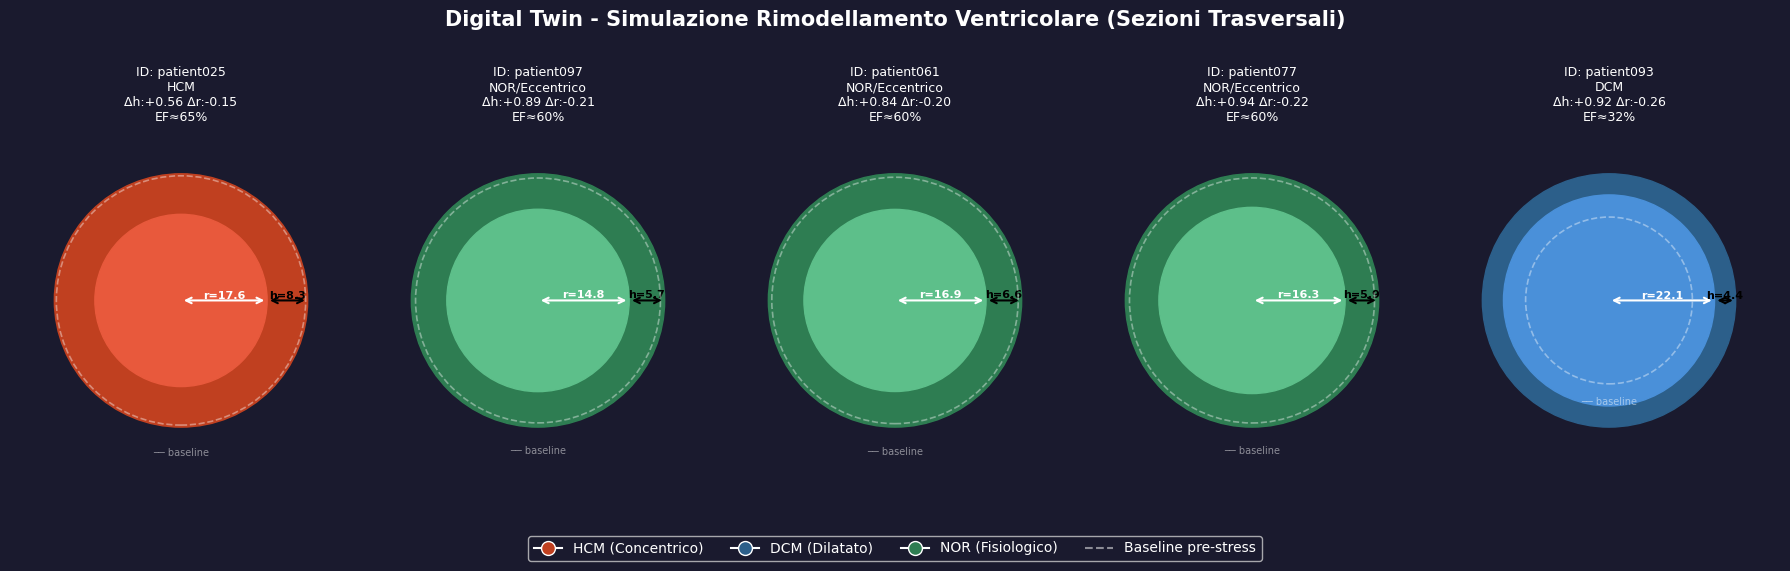

In [21]:
# =============================================================================
# CELL 11 — Visualizzazione rimodellamento finale per paziente (AGGIORNATA)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.lines import Line2D

# 1. FUNZIONI DI SUPPORTO (Invariate o leggermente ottimizzate)
def disegna_sezione_lv(ax, r, h, colore_cavita, colore_parete, titolo, ef=None):
    r_esterno = r + h
    cerchio_esterno = plt.Circle((0, 0), r_esterno, color=colore_parete, zorder=1)
    cerchio_interno = plt.Circle((0, 0), r, color=colore_cavita, zorder=2)
    ax.add_patch(cerchio_esterno)
    ax.add_patch(cerchio_interno)

    ax.annotate("", xy=(r, 0), xytext=(0, 0), arrowprops=dict(arrowstyle="<->", color="white", lw=1.5))
    ax.text(r / 2, 0.4, f"r={r:.1f}", color="white", ha="center", fontsize=8, fontweight="bold")
    ax.annotate("", xy=(r_esterno, 0), xytext=(r, 0), arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
    ax.text(r + h / 2, 0.4, f"h={h:.1f}", color="black", ha="center", fontsize=8, fontweight="bold")

    lim = r_esterno * 1.35
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(titolo + (f"\nEF≈{ef:.0f}%" if ef else ""), fontsize=9, color="white", pad=6)

def colori_per_fenotipo(fenotipo):
    if fenotipo == "HCM": return "#E8593C", "#C04020"
    if fenotipo == "DCM": return "#4A90D9", "#2C5F8A"
    return "#5DBF8A", "#2E7D52"

# 2. SELEZIONE DEI CAMPIONI DAL TEST SET
# Cerchiamo i casi più estremi nei risultati delle simulazioni precedenti
campione_hcm = df_hcm.sort_values("h/r ratio", ascending=False).iloc[0] if not df_hcm.empty else None
campione_dcm = df_dcm.sort_values("h/r ratio", ascending=True).iloc[0] if not df_dcm.empty else None
campioni_nor = df_hcm[df_hcm["Diagnosi"] == "NOR/Eccentrico"].head(3)

# Funzione per trovare l'oggetto HeteroData nel test_nor partendo dall'ID stringa
def get_paziente_by_id(pid):
    for p in pazienti_nor: # Cerchiamo nel pool totale
        if p.patient_id == pid: return p
    return None

pazienti_da_mostrare = []
if campione_hcm is not None: pazienti_da_mostrare.append({"id": campione_hcm["Paziente"], "fenotipo": "HCM", "row": campione_hcm})
for _, row in campioni_nor.iterrows(): pazienti_da_mostrare.append({"id": row["Paziente"], "fenotipo": "NOR/Eccentrico", "row": row})
if campione_dcm is not None: pazienti_da_mostrare.append({"id": campione_dcm["Paziente"], "fenotipo": "DCM", "row": campione_dcm})

# 3. LAYOUT E DISEGNO
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.patch.set_facecolor("#1a1a2e")

for ax, pz in zip(axes, pazienti_da_mostrare):
    ax.set_facecolor("#1a1a2e")
    data_orig = get_paziente_by_id(pz["id"])
    row = pz["row"]
    
    # Feature finali predette
    r_f, h_f = float(row["r_finale"]), float(row["h_finale"])
    
    # Feature base originali (Estratte correttamente dai nodi state/tissue)
    r_b = data_orig['state'].x[0, 1].item()
    h_b = data_orig['tissue'].x[:, 0].mean().item()
    
    col_cav, col_par = colori_per_fenotipo(pz["fenotipo"])
    ef_sim = {"HCM": 65.0, "DCM": 32.0, "NOR/Eccentrico": 60.0}[pz["fenotipo"]]

    titolo = f"ID: {pz['id']}\n{pz['fenotipo']}\nΔh:{row['Δh (px)']:+.2f} Δr:{row['Δr (px)']:+.2f}"
    disegna_sezione_lv(ax, r_f, h_f, col_cav, col_par, titolo, ef=ef_sim)

    # Aggiunta cerchio baseline (tratteggiato)
    r_ext_b = r_b + h_b
    ax.add_patch(plt.Circle((0, 0), r_ext_b, fill=False, edgecolor="white", linestyle="--", linewidth=1.2, alpha=0.4, zorder=5))
    ax.text(0, -(r_ext_b * 1.25), "── baseline", color="white", alpha=0.5, ha="center", fontsize=7)

# 4. LEGENDA E FINITURA
legenda = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#C04020', markersize=10, label='HCM (Concentrico)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2C5F8A', markersize=10, label='DCM (Dilatato)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E7D52', markersize=10, label='NOR (Fisiologico)'),
    Line2D([0], [0], color='white', linestyle='--', alpha=0.5, label='Baseline pre-stress')
]
fig.legend(handles=legenda, loc="lower center", ncol=4, facecolor="#1a1a2e", labelcolor="white", fontsize=10, bbox_to_anchor=(0.5, 0.05))
plt.suptitle("Digital Twin - Simulazione Rimodellamento Ventricolare (Sezioni Trasversali)", color="white", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

 FASE 1: SHOCK MECCANICO E RISPOSTA ELASTICA
Stato Sano : r = 30.77, h = 13.55
Trigger DCM: Raggio dilatato a 49.24 (+60%)

 FASE 2: EVOLUZIONE TEMPORALE (GNN + EULERO)
Anno 00 | Stress: 313.3 | h/r: 0.192 | Massa: 100.0%
Anno 05 | Stress: 268.8 | h/r: 0.223 | Massa: 114.6%
[!!!] MESE 84: BURNOUT! La massa si ferma al 120%.
Anno 10 | Stress: 251.2 | h/r: 0.239 | Massa: 120.1%
Anno 15 | Stress: 244.9 | h/r: 0.245 | Massa: 120.1%
Anno 20 | Stress: 238.9 | h/r: 0.251 | Massa: 120.1%


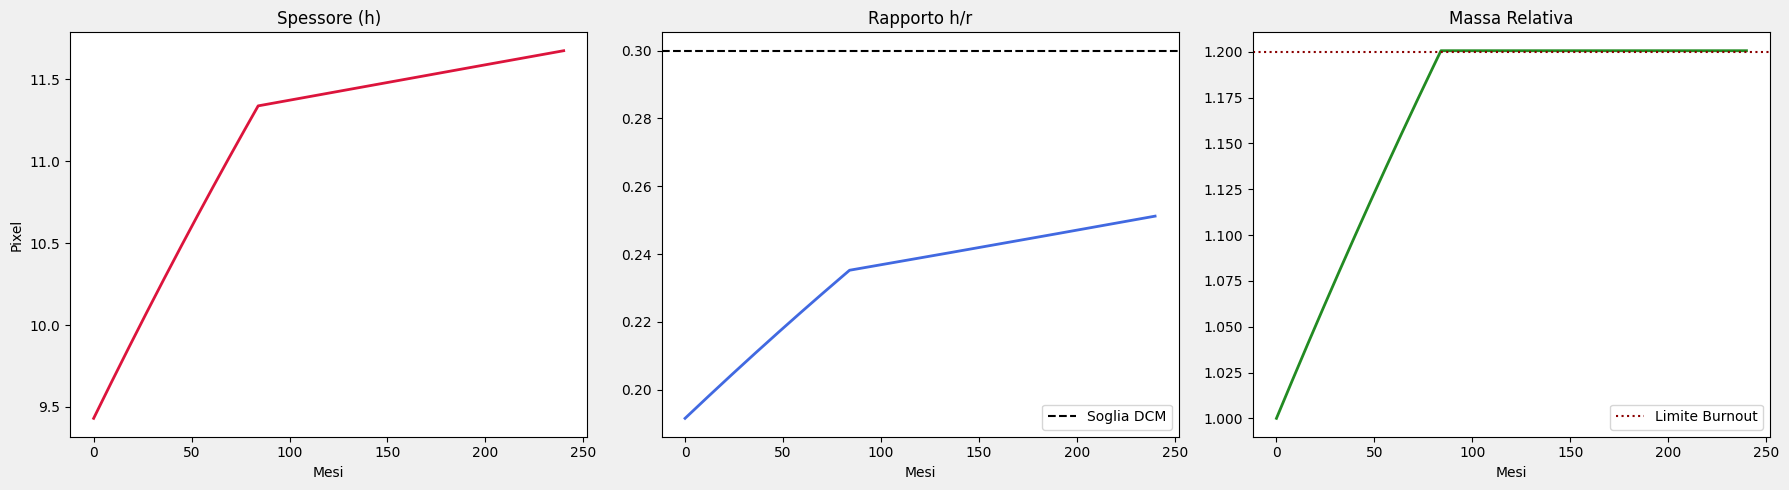

In [22]:
import math
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def simula_traiettoria_temporale_corretta(model, paziente_base, trigger_raggio=1.0, trigger_pressione=1.0, mesi=24, dt=1.0):
    model.eval()
    
    # Cloniamo il grafo per non modificare l'originale
    grafo_t = paziente_base.clone()
    
    # 1. STATO FISIOLOGICO SANO (T=-1)
    # Lettura corretta dalla nuova topologia: raggio da 'state', spessore da 'tissue'
    r_sano = grafo_t['state'].x[0, 1].item() 
    h_sano = grafo_t['tissue'].x[:, 0].mean().item()
    p_base = 120.0 # Pressione sistolica baseline
    
    # Area del miocardio (massa geometrica 2D) che deve conservarsi durante lo shock elastico
    area_sana_vera = (h_sano**2 + 2 * r_sano * h_sano) 
    
    # 2. COLPO MECCANICO (T=0) - Risposta elastica istantanea
    p_corrente = p_base * trigger_pressione
    r_corrente = r_sano * trigger_raggio
    
    # Assottigliamento/Ispessimento elastico istantaneo (conservazione massa a T=0)
    h_corrente = math.sqrt(r_corrente**2 + area_sana_vera) - r_corrente
    
    print("=" * 60)
    print(" FASE 1: SHOCK MECCANICO E RISPOSTA ELASTICA")
    print("=" * 60)
    print(f"Stato Sano : r = {r_sano:.2f}, h = {h_sano:.2f}")
    if trigger_raggio != 1.0:
        print(f"Trigger DCM: Raggio dilatato a {r_corrente:.2f} (+{(trigger_raggio-1)*100:.0f}%)")
    
    print("\n" + "=" * 60)
    print(" FASE 2: EVOLUZIONE TEMPORALE (GNN + EULERO)")
    print("=" * 60)
    
    storia = {'mese': [], 'h': [], 'r': [], 'ratio': [], 'massa_rel': [], 'stress': []}
    massa_relativa = 1.0 
    tau = 12.0 # Costante di tempo (mesi) per rendere il rimodellamento graduale
    burnout_raggiunto = False 
    
    with torch.no_grad():
        for t in range(int(mesi / dt) + 1):
            mese_attuale = t * dt
            
            # Legge di Laplace per lo stress parietale corrente
            stress_t = (p_corrente * r_corrente) / (2.0 * h_corrente + 1e-6)
            
            storia['mese'].append(mese_attuale)
            storia['h'].append(h_corrente)
            storia['r'].append(r_corrente)
            storia['ratio'].append(h_corrente / r_corrente)
            storia['massa_rel'].append(massa_relativa)
            storia['stress'].append(stress_t)
            
            # --- AGGIORNAMENTO GRAFO PER GNN ---
            # Inseriamo i dati correnti nei nodi giusti
            grafo_t['state'].x[0, 1] = r_corrente  # Raggio diastolico
            grafo_t['tissue'].x[:, 0] = h_corrente # Spessore parete
            # Aggiorniamo h/r ratio nel nodo chamber (usato come feature)
            grafo_t['chamber'].x[:, 1] = h_corrente / r_corrente 
            
            # Forward pass della GNN
            out = model(grafo_t.x_dict, grafo_t.edge_index_dict)
            
            # Calcolo attivazione basata sullo stress
            activation = max(0.0, stress_t - 120.0) / (stress_t + 1e-6)
            
            # --- TASSI DI CRESCITA DALLA GNN ---
            # tasso_dr: estratto dal nodo 'state' (indice 0=ED, indice 1=feature raggio)
            tasso_dr = (torch.clamp(out['delta_state'][0, 1], -4.0, 4.0).item() * activation) / tau
            
            # tasso_dm: estratto dal nodo 'tissue' (indice 1=feature massa)
            tasso_dm = (torch.clamp(out['delta_tissue'][:, 1], -1.0, 0.05).mean().item() * activation) / tau
            
            # --- LOGICA BURNOUT METABOLICO ---
            if massa_relativa >= 1.20:
                tasso_dm = 0.0 
                if not burnout_raggiunto:
                    print(f"[!!!] MESE {mese_attuale}: BURNOUT! La massa si ferma al 120%.")
                    burnout_raggiunto = True
            
            if mese_attuale % 60 == 0:
                print(f"Anno {int(mese_attuale/12):02d} | Stress: {stress_t:.1f} | h/r: {storia['ratio'][-1]:.3f} | Massa: {massa_relativa*100:.1f}%")
            
            # --- AGGIORNAMENTO EULERO ---
            massa_relativa += (tasso_dm * dt)
            r_nuovo = r_corrente + (tasso_dr * dt)
            
            # Calcoliamo il nuovo h basandoci sulla nuova massa (area_target) e nuovo raggio
            area_target = area_sana_vera * massa_relativa
            radicando = r_nuovo**2 + area_target
            
            if radicando < 0:
                print("\n[!] Collasso cardiaco simulato.")
                break
                
            h_corrente = math.sqrt(radicando) - r_nuovo
            r_corrente = r_nuovo

    return storia

# --- ESECUZIONE SIMULAZIONE ---
# Usiamo il primo paziente del test set
storia_dcm = simula_traiettoria_temporale_corretta(
    model_pop, test_nor[0], 
    trigger_raggio=1.6, # Simulazione Dilatativa
    mesi=240, dt=1
)

# Plotting dei risultati
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#f0f0f0')

axs[0].plot(storia_dcm['mese'], storia_dcm['h'], color='crimson', lw=2)
axs[0].set_title("Spessore (h)")
axs[0].set_ylabel("Pixel")

axs[1].plot(storia_dcm['mese'], storia_dcm['ratio'], color='royalblue', lw=2)
axs[1].axhline(y=0.30, color='black', linestyle='--', label="Soglia DCM")
axs[1].set_title("Rapporto h/r")
axs[1].legend()

axs[2].plot(storia_dcm['mese'], storia_dcm['massa_rel'], color='forestgreen', lw=2)
axs[2].axhline(y=1.20, color='darkred', linestyle=':', label="Limite Burnout")
axs[2].set_title("Massa Relativa")
axs[2].legend()

for ax in axs: ax.set_xlabel("Mesi")
plt.tight_layout()
plt.show()

 FASE 1: SHOCK MECCANICO E RISPOSTA ELASTICA
Stato Sano : r = 30.77, h = 13.55

 FASE 2: EVOLUZIONE TEMPORALE (GNN + EULERO)
Anno 00 | Stress: 231.6 | h/r: 0.440 | Massa: 100.0%
Anno 05 | Stress: 205.2 | h/r: 0.497 | Massa: 111.2%
[!!!] MESE 115.0: BURNOUT! La massa si ferma al 120%.
Anno 10 | Stress: 187.3 | h/r: 0.545 | Massa: 120.1%
Anno 15 | Stress: 182.7 | h/r: 0.558 | Massa: 120.1%


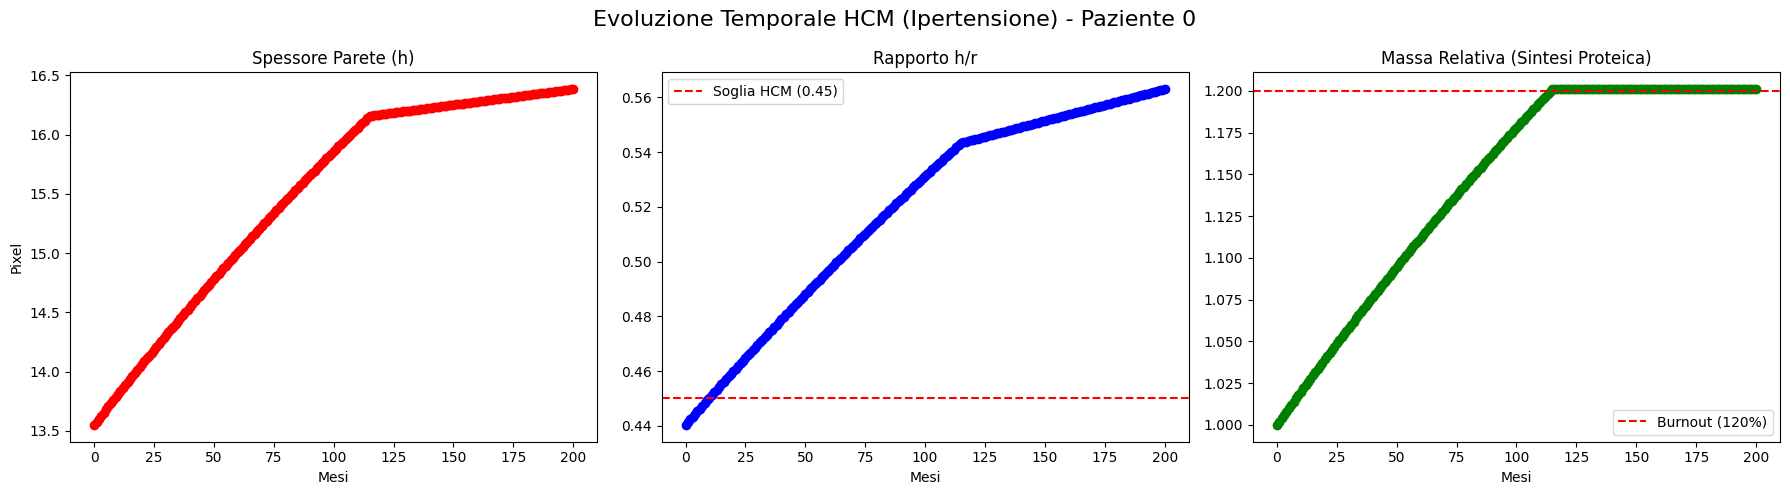

In [23]:
# =============================================================================
# ESECUZIONE E PLOT SUL PAZIENTE 0 DEL TEST SET (TRIGGER HCM)
# =============================================================================

paziente_id = 0
storia_hcm = simula_traiettoria_temporale_corretta(
    model_pop, test_nor[paziente_id], 
    trigger_raggio=1.0,         # Nessuna dilatazione iniziale (raggio invariato)
    trigger_pressione=1.7,      # Ipertensione severa (+50% di pressione)
    mesi=200, dt=1.0            # 200 mesi per vedere tutto il ciclo di vita
)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Evoluzione Temporale HCM (Ipertensione) - Paziente {paziente_id}", fontsize=16)

axs[0].plot(storia_hcm['mese'], storia_hcm['h'], color='red', marker='o')
axs[0].set_title("Spessore Parete (h)")
axs[0].set_xlabel("Mesi")
axs[0].set_ylabel("Pixel")

axs[1].plot(storia_hcm['mese'], storia_hcm['ratio'], color='blue', marker='o')
# ATTENZIONE: Qui la soglia è quella superiore per l'ipertrofia (0.45)
axs[1].axhline(y=0.45, color='red', linestyle='--', label="Soglia HCM (0.45)")
axs[1].set_title("Rapporto h/r")
axs[1].set_xlabel("Mesi")
axs[1].legend()

axs[2].plot(storia_hcm['mese'], storia_hcm['massa_rel'], color='green', marker='o')
axs[2].axhline(y=1.20, color='red', linestyle='--', label="Burnout (120%)")
axs[2].set_title("Massa Relativa (Sintesi Proteica)")
axs[2].set_xlabel("Mesi")
axs[2].legend()

plt.tight_layout()
plt.savefig('evoluzione_hcm.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
import math
import torch
import torch.nn.functional as F

def simula_traiettoria_temporale_corretta(model, paziente_base, trigger_raggio=1.0, trigger_pressione=1.0, mesi=24, dt=1.0):
    model.eval()
    
    grafo_t = paziente_base.clone()
    p_base = 120.0 # Pressione sistolica di base
    
    # 1. STATO FISIOLOGICO SANO (T=-1)
    # Estrazione con la nuova topologia: raggio da 'state', spessore da 'tissue'
    r_sano = grafo_t['state'].x[0, 1].item()
    h_sano = grafo_t['tissue'].x[:, 0].mean().item()
    
    # Massa/Area vera di partenza
    area_sana_vera = (h_sano**2 + 2 * r_sano * h_sano) 
    
    # 2. COLPO MECCANICO (T=0) - Elasticità passiva
    p_corrente = p_base * trigger_pressione
    r_corrente = r_sano * trigger_raggio
    
    # Assottigliamento elastico istantaneo
    h_corrente = math.sqrt(r_corrente**2 + area_sana_vera) - r_corrente
    
    storia = {'mese': [], 'h': [], 'r': [], 'ratio': [], 'massa_rel': [], 'stress': []}
    massa_relativa = 1.0 
    tau = 6.0 # Costante di tempo biologica (mesi)
    
    with torch.no_grad():
        for t in range(int(mesi / dt) + 1):
            mese_attuale = t * dt
            # stress_t è un normale float Python
            stress_t = (p_corrente * r_corrente) / (2.0 * h_corrente + 1e-6)
            
            storia['mese'].append(mese_attuale)
            storia['h'].append(h_corrente)
            storia['r'].append(r_corrente)
            storia['ratio'].append(h_corrente / r_corrente)
            storia['massa_rel'].append(massa_relativa)
            storia['stress'].append(stress_t)
            
            # Aggiorniamo il grafo per la GNN
            grafo_t['state'].x[0, 1] = r_corrente # Raggio aggiornato nello stato diastolico
            grafo_t['tissue'].x[:, 0] = h_corrente # Spessore aggiornato
            # La feature di ratio h/r nel nodo chamber va tenuta sincronizzata
            grafo_t['chamber'].x[:, 1] = h_corrente / r_corrente 
            
            out = model(grafo_t.x_dict, grafo_t.edge_index_dict)
            
            # Attivazione usando matematica pura
            activation = max(0.0, stress_t - 120.0) / (stress_t + 1e-6)
            
            # Tassi di crescita
            # Δr estratto dal nodo temporale state
            tasso_dr = (torch.clamp(out['delta_state'][0, 1], -4.0, 4.0).item() * activation) / tau
            
            # Δm estratto dal tissue con clamp di sicurezza biologica
            tasso_dm = (torch.clamp(out['delta_tissue'][:, 1], -1.0, 0.05).mean().item() * activation) / tau            
            
            # Burnout Metabolico (Rimosso anche qui il print dell'allarme)
            if massa_relativa >= 1.20:
                tasso_dm = 0.0 
        
            # Aggiornamento Euler
            massa_relativa += (tasso_dm * dt)
            r_nuovo = r_corrente + (tasso_dr * dt)
            
            area_target = area_sana_vera * massa_relativa
            radicando = r_nuovo**2 + area_target
            
            if radicando < 0:
                # Interruzione in caso di collasso matematico
                break
                
            # Calcolo del nuovo h con math.sqrt
            h_nuovo = math.sqrt(radicando) - r_nuovo
            
            h_corrente = h_nuovo
            r_corrente = r_nuovo

    return storia

Inizio screening su 13 pazienti del Test Set...
Scenario: Ipertensione Severa (Pressione +60%)
--------------------------------------------------------------------------------
ID           | Raggio  | h Base  | Ratio Base | Ratio Max  | Esito
--------------------------------------------------------------------------------
patient057   | 30.77   | 13.55   | 0.440      | 0.634      | HCM GRAVE
patient097   | 14.99   | 4.85    | 0.324      | 0.748      | HCM GRAVE
patient061   | 17.10   | 5.76    | 0.337      | 0.725      | HCM GRAVE
patient077   | 16.48   | 4.92    | 0.298      | 0.722      | HCM GRAVE
patient025   | 17.77   | 7.73    | 0.435      | 0.742      | HCM GRAVE
patient093   | 13.99   | 3.50    | 0.250      | 0.752      | HCM GRAVE
patient092   | 13.67   | 3.93    | 0.288      | 0.753      | HCM GRAVE
patient084   | 12.68   | 3.24    | 0.256      | 0.766      | HCM GRAVE
patient003   | 18.99   | 5.72    | 0.301      | 0.629      | HCM GRAVE
patient013   | 20.22   | 6.86    | 0.

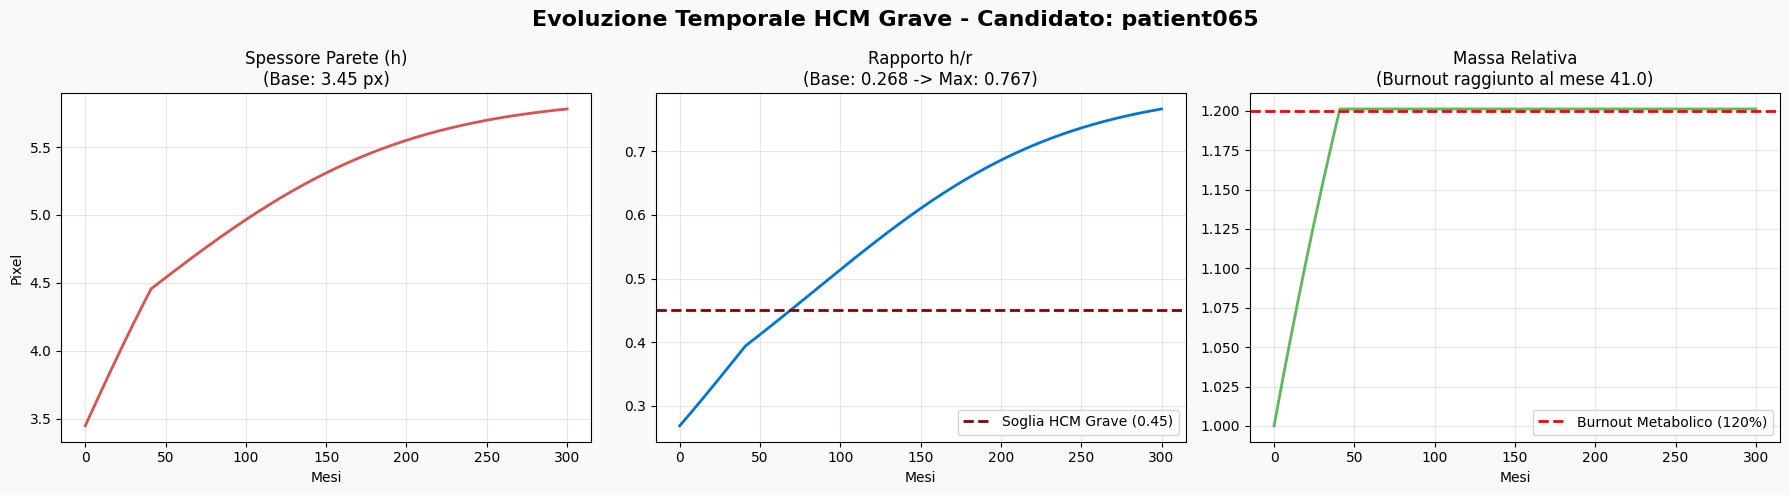

Grafico 'best_hcm_candidate.png' salvato con successo.


In [25]:
# =============================================================================
# SCREENING SISTEMATICO HCM PULITO: RICERCA E PLOT DEL "BEST CASE" (AGGIORNATO)
# =============================================================================
import matplotlib.pyplot as plt

pazienti_hcm_gravi = []
best_patient_ever = None
max_ratio_found = 0

# Reset dei plot precedenti per sicurezza
plt.close('all')

print(f"Inizio screening su {len(test_nor)} pazienti del Test Set...")
print("Scenario: Ipertensione Severa (Pressione +60%)")
print("-" * 80)
print(f"{'ID':<12} | {'Raggio':<7} | {'h Base':<7} | {'Ratio Base':<10} | {'Ratio Max':<10} | {'Esito'}")
print("-" * 80)

for idx, paziente in enumerate(test_nor):
    # 1. Estrazione dati basali (Nuova Topologia)
    # Raggio dallo stato diastolico (state index 0, feat 1)
    r_base = paziente['state'].x[0, 1].item()
    # Spessore dal nodo tissue (feat 0)
    h_base = paziente['tissue'].x[:, 0].mean().item()
    ratio_base = h_base / r_base
    
    # ID originale del paziente (stringa)
    pat_id_str = paziente.patient_id if hasattr(paziente, 'patient_id') else f"Pz_{idx}"

    # 2. Simulazione silenziosa a lungo termine
    # La funzione simula_traiettoria_temporale_corretta deve essere quella aggiornata prima
    storia = simula_traiettoria_temporale_corretta(
        model_pop, 
        paziente, 
        trigger_raggio=1.0,          
        trigger_pressione=1.6,      # Ipertensione severa (+60%)
        mesi=300, 
        dt=1.0
    )
    
    # 3. Analisi dei risultati
    rapporto_massimo = max(storia['ratio'])
    
    # Check se è il migliore trovato finora
    if rapporto_massimo > max_ratio_found:
        max_ratio_found = rapporto_massimo
        best_patient_ever = {
            'idx': idx,
            'paziente_id': pat_id_str,
            'storia': storia,
            'ratio_base': ratio_base
        }

    status = "HCM GRAVE" if rapporto_massimo >= 0.45 else "HCM LIEVE"
    
    # Stampa formattata
    print(f"{pat_id_str:<12} | {r_base:<7.2f} | {h_base:<7.2f} | {ratio_base:<10.3f} | {rapporto_massimo:<10.3f} | {status}")
    
    if rapporto_massimo >= 0.45:
        pazienti_hcm_gravi.append(pat_id_str)

# --- CONCLUSIONI E VERDETTO FINALE ---
print("\n" + "="*80)
print(" VERDETTO FINALE DELLO SCREENING")
print("="*80)
print(f"Pazienti totali testati: {len(test_nor)}")
print(f"Pazienti HCM Gravi (>=0.45): {len(pazienti_hcm_gravi)}")
print(f"Percentuale di successo: {(len(pazienti_hcm_gravi)/len(test_nor))*100:.1f}%")
print("-" * 80)

# --- GENERAZIONE DEL PLOT SOLO PER IL "BEST CASE" ---
if best_patient_ever is not None:
    bp = best_patient_ever
    print(f"\nGenerazione grafici per il miglior candidato: {bp['paziente_id']} (Max Ratio: {max_ratio_found:.3f})")
    
    storia = bp['storia']
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor('#f8f9fa')
    fig.suptitle(f"Evoluzione Temporale HCM Grave - Candidato: {bp['paziente_id']}", fontsize=16, fontweight='bold')
    
    # Plot Spessore
    axs[0].plot(storia['mese'], storia['h'], color='#d9534f', lw=2)
    axs[0].set_title(f"Spessore Parete (h)\n(Base: {storia['h'][0]:.2f} px)")
    axs[0].set_xlabel("Mesi")
    axs[0].set_ylabel("Pixel")
    axs[0].grid(True, alpha=0.3)
    
    # Plot Ratio con soglia
    axs[1].plot(storia['mese'], storia['ratio'], color='#0275d8', lw=2)
    axs[1].axhline(y=0.45, color='darkred', linestyle='--', linewidth=2, label="Soglia HCM Grave (0.45)")
    axs[1].set_title(f"Rapporto h/r\n(Base: {bp['ratio_base']:.3f} -> Max: {max_ratio_found:.3f})")
    axs[1].set_xlabel("Mesi")
    axs[1].legend(loc='lower right')
    axs[1].grid(True, alpha=0.3)
    
    # Plot Massa con soglia burnout
    axs[2].plot(storia['mese'], storia['massa_rel'], color='#5cb85c', lw=2)
    axs[2].axhline(y=1.20, color='red', linestyle='--', linewidth=2, label="Burnout Metabolico (120%)")
    
    # Calcolo mese di burnout
    try:
        mese_burnout = storia['mese'][storia['massa_rel'].index(max(storia['massa_rel']))]
        title_massa = f"Massa Relativa\n(Burnout raggiunto al mese {mese_burnout})"
    except:
        title_massa = "Massa Relativa"
        
    axs[2].set_title(title_massa)
    axs[2].set_xlabel("Mesi")
    axs[2].legend(loc='lower right')
    axs[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('best_hcm_candidate.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Grafico 'best_hcm_candidate.png' salvato con successo.")
else:
    print("\nNessun grafico generato: nessun paziente ha raggiunto la soglia patologica.")